✅ '/Users/gyuminkang/Desktop/solar/InfraredSolarModules/module_metadata.json' 에서 데이터를 로딩 중입니다...

[데이터셋 기본 통계]
총 이미지(데이터) 개수: 20,000개

[클래스별 데이터 분포 요약]
                이미지 수(Count)  비율(%)
anomaly_class                      
No-Anomaly             10000  50.00
Cell                    1877   9.38
Vegetation              1639   8.20
Diode                   1499   7.50
Cell-Multi              1288   6.44
Shadowing               1056   5.28
Cracking                 940   4.70
Offline-Module           827   4.14
Hot-Spot                 249   1.24
Hot-Spot-Multi           246   1.23
Soiling                  204   1.02
Diode-Multi              175   0.88


/var/folders/6n/mqz2xk3n1xd0qw_wj934y6br0000gn/T/ipykernel_34186/3722676934.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


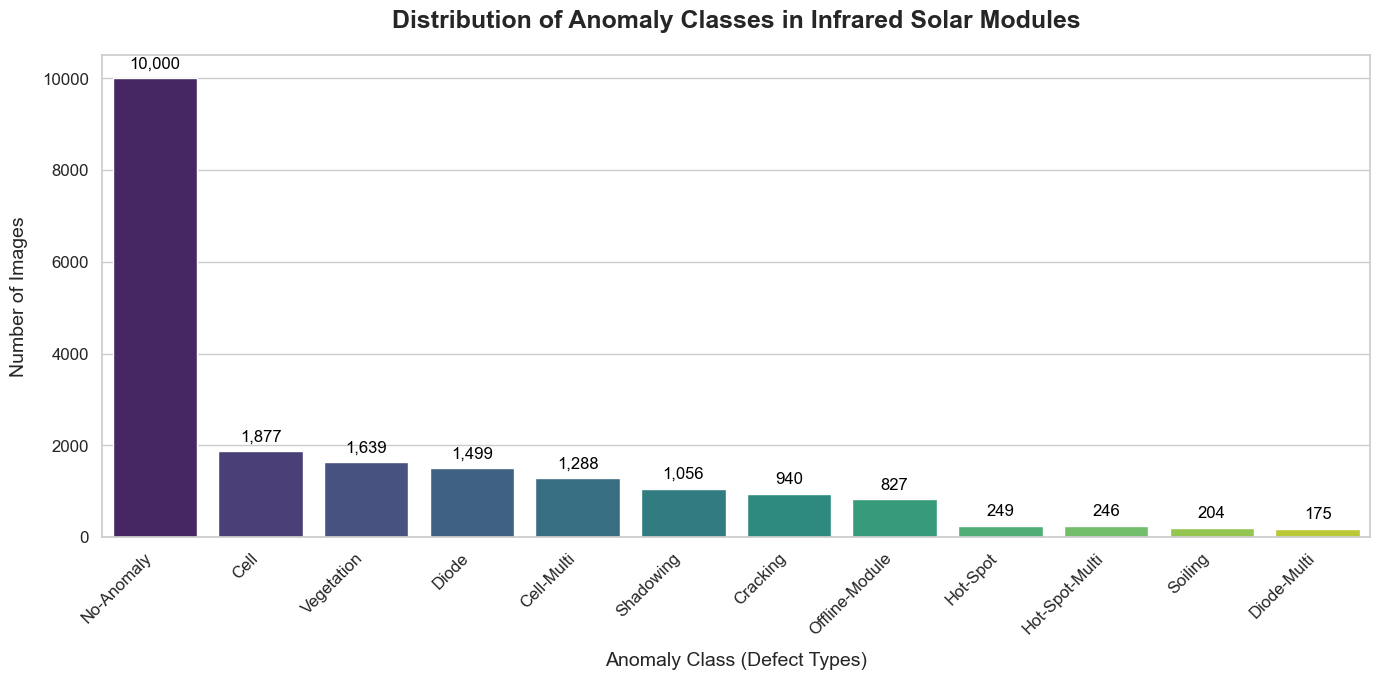

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_solar_modules_distribution(base_path):
    # 1. 파일 경로 설정 (검증된 구조에 따라 metadata json 파일 참조)
    metadata_path = os.path.join(base_path, 'module_metadata.json')
    
    if not os.path.exists(metadata_path):
        print(f"❌ [오류] '{metadata_path}' 파일을 찾을 수 없습니다.")
        print("해당 경로에 module_metadata.json 파일이 존재하는지 확인해주세요.")
        return

    # 2. JSON 데이터 로드
    print(f"✅ '{metadata_path}' 에서 데이터를 로딩 중입니다...")
    try:
        # InfraredSolarModules 데이터셋의 표준 포맷 반영 (orient='index')
        df = pd.read_json(metadata_path, orient='index')
    except Exception as e:
        print(f"❌ [오류] 데이터 로딩 실패: {e}")
        return

    # 3. 데이터셋 전체 통계 확인
    print("\n" + "="*50)
    print("[데이터셋 기본 통계]")
    print(f"총 이미지(데이터) 개수: {len(df):,}개")
    print("="*50)

    # 4. 클래스 분포 분석 (anomaly_class 기준)
    if 'anomaly_class' in df.columns:
        # value_counts()는 자동으로 빈도수 기준 내림차순 정렬을 수행합니다.
        counts = df['anomaly_class'].value_counts()
        ratios = df['anomaly_class'].value_counts(normalize=True) * 100
        
        dist_df = pd.DataFrame({
            '이미지 수(Count)': counts, 
            '비율(%)': ratios.round(2)
        })
        
        print("\n[클래스별 데이터 분포 요약]")
        print(dist_df.to_string())
        
        # 5. 데이터 분포 시각화 (Bar Chart)
        plt.figure(figsize=(14, 7))
        # 최신 트렌드에 맞는 깔끔한 테마 적용
        sns.set_theme(style="whitegrid", font_scale=1.1)
        
        # 시각화 생성 (정렬된 상태 유지)
        ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")
        
        # 차트 제목 및 라벨 설정
        plt.title('Distribution of Anomaly Classes in Infrared Solar Modules', 
                  fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('Anomaly Class (Defect Types)', fontsize=14, labelpad=10)
        plt.ylabel('Number of Images', fontsize=14, labelpad=10)
        
        # X축 라벨이 잘리거나 겹치지 않도록 회전 및 정렬
        plt.xticks(rotation=45, ha='right')
        
        # 각 막대 상단에 정확한 수치 추가
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{int(height):,}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=12, color='black', 
                        xytext=(0, 5), textcoords='offset points')
        
        # 레이아웃 자동 최적화
        plt.tight_layout()
        plt.show()
    else:
        print("\n❌ [오류] 데이터 내에 'anomaly_class' 열이 존재하지 않습니다.")
        print(f"현재 로드된 데이터의 열 목록: {df.columns.tolist()}")

# 사용자 지정 경로 실행
DATASET_PATH = '/Users/gyuminkang/Desktop/solar/InfraredSolarModules'
analyze_solar_modules_distribution(DATASET_PATH)